# The Fare Amount Prediction Of Future Rides Using Regression Analysis

In [1]:
# importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, datetime
from sklearn.preprocessing import MinMaxScaler
from math import sin, cos, sqrt, radians, atan2 
from sklearn.model_selection import train_test_split

import warnings as wrn
wrn.filterwarnings ('ignore')

In [2]:
# to load the data

uber_data = pd.read_csv("F:\\Mentormind\\uber.csv")
uber_data.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [3]:
# total cells in the table

uber_data.size

1800000

In [4]:
# total rows & columns

uber_data.shape

(200000, 9)

In [5]:
# to find the data-type & Non-Null values

uber_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [6]:
# to find the total null values 

uber_data.isna().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [7]:
# to find the list of all the columns in the dataset

uber_data.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [8]:
# to find the index of row having null value
uber_data.loc[uber_data['dropoff_longitude'].isnull(), ]

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,2013-07-02 03:51:57.0000001,24.1,2013-07-02 03:51:57 UTC,-73.950581,40.779692,NaN,NaN,0


In [9]:
# to extract the 'fare_amount' column from the table
col = uber_data.pop('fare_amount')

In [10]:
# to re-arrange the target column in the end
uber_data.insert(8, 'fare_amount', col)

In [11]:
uber_data.head(5)

,Unnamed: 0,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,fare_amount
0,24238194,2015-05-07 19:52:06.0000003,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,7.5
1,27835199,2009-07-17 20:04:56.0000002,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,7.7
2,44984355,2009-08-24 21:45:00.00000061,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,12.9
3,25894730,2009-06-26 08:22:21.0000001,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,5.3
4,17610152,2014-08-28 17:47:00.000000188,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,16.0


## Missing-value

In [12]:
# as we have only 2 missing value in the same row , and the missing values are the coordinates of the location , so instead of fill 
# these we will drop that onw row.....

uber_data.drop(87946, axis = 0, inplace = True)

In [13]:
# new shape after removing one row
uber_data.shape

(199999, 9)

In [14]:
uber_data.head(5)

,Unnamed: 0,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,fare_amount
0,24238194,2015-05-07 19:52:06.0000003,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,7.5
1,27835199,2009-07-17 20:04:56.0000002,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,7.7
2,44984355,2009-08-24 21:45:00.00000061,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,12.9
3,25894730,2009-06-26 08:22:21.0000001,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,5.3
4,17610152,2014-08-28 17:47:00.000000188,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,16.0


## Feature-engineering 

In [15]:
uber_data.shape

(199999, 9)

In [16]:
# as column 'pickup_datetime' data-type is object , so further using it, we will have to change the data-type into datetime..
uber_data['pickup_datetime'] = pd.to_datetime(uber_data['pickup_datetime'])

In [17]:
# to extract 'day' from the date....
uber_data.insert(3, 'pickup_day', uber_data['pickup_datetime'].dt.dayofweek)

In [18]:
# to extract exact 'hour' from the time...
uber_data.insert(4, 'pickup_hour', uber_data['pickup_datetime'].dt.hour)

In [19]:
# to extract 'month' from the date...
uber_data.insert(5, 'pickup_month', uber_data['pickup_datetime'].dt.month)

In [20]:
# to extract 'year' from the date..
uber_data.insert(6, 'pickup_year', uber_data['pickup_datetime'].dt.year)

In [21]:
uber_data.head(5)

,Unnamed: 0,key,pickup_datetime,pickup_day,pickup_hour,pickup_month,pickup_year,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,fare_amount
0,24238194,2015-05-07 19:52:06.0000003,2015-05-07 19:52:06+00:00,3,19,5,2015,-73.999817,40.738354,-73.999512,40.723217,1,7.5
1,27835199,2009-07-17 20:04:56.0000002,2009-07-17 20:04:56+00:00,4,20,7,2009,-73.994355,40.728225,-73.994710,40.750325,1,7.7
2,44984355,2009-08-24 21:45:00.00000061,2009-08-24 21:45:00+00:00,0,21,8,2009,-74.005043,40.740770,-73.962565,40.772647,1,12.9
3,25894730,2009-06-26 08:22:21.0000001,2009-06-26 08:22:21+00:00,4,8,6,2009,-73.976124,40.790844,-73.965316,40.803349,3,5.3
4,17610152,2014-08-28 17:47:00.000000188,2014-08-28 17:47:00+00:00,3,17,8,2014,-73.925023,40.744085,-73.973082,40.761247,5,16.0


In [22]:
uber_data.shape

(199999, 13)

In [23]:
# now as we have extracted all date and time columns, we can drop these columns...
uber_data.drop(['pickup_datetime', 'Unnamed: 0', 'key'], axis = 1, inplace = True)

In [24]:
uber_data.shape

(199999, 10)

### -- to extract "Distance" from these co-ordinates (given for the location) 

In [25]:
data = uber_data[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude','dropoff_latitude',]]

In [26]:
data.head(3)

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,-73.999817,40.738354,-73.999512,40.723217
1,-73.994355,40.728225,-73.994710,40.750325
2,-74.005043,40.740770,-73.962565,40.772647


In [27]:
# to create a function for extracting distance (in km) from co-ordinates..
def distance(data):
    R = 6373.0
    data['pickup_longitude'] = data['pickup_longitude'].apply(radians)
    data['pickup_latitude'] = data['pickup_latitude'].apply(radians)
    data['dropoff_longitude'] = data['dropoff_longitude'].apply(radians)
    data['dropoff_latitude'] = data['dropoff_latitude'].apply(radians)

    data['long_diff'] = data['dropoff_longitude'] - data['pickup_longitude']
    data['lat_diff'] = data['dropoff_latitude'] - data['pickup_latitude']
    
    data['intermediaire'] = (data['lat_diff']/2).apply(sin)**2 + data['pickup_latitude'].apply(cos) * data['dropoff_latitude'].apply(cos) *  (data['long_diff']/2).apply(sin)**2

    data['distance'] = R*np.atan2((data['intermediaire']).apply(sqrt), (1- data['intermediaire']).apply(sqrt))

    return data

In [28]:
# created the distance column
distance(data)

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,long_diff,lat_diff,intermediaire,distance
0,-1.291540,0.711018,-1.291535,0.710754,0.000005,-0.000264,1.745258e-08,0.841926
1,-1.291445,0.710842,-1.291451,0.711227,-0.000006,0.000386,3.720006e-08,1.229181
2,-1.291632,0.711061,-1.290890,0.711617,0.000741,0.000556,1.562289e-07,2.518979
3,-1.291127,0.711935,-1.290938,0.712153,0.000189,0.000218,1.700675e-08,0.831103
4,-1.290235,0.711118,-1.291074,0.711418,-0.000839,0.000300,1.233668e-07,2.238427
...,...,...,...,...,...,...,...,...
199995,-1.291317,0.711036,-1.291308,0.711052,0.000009,0.000016,7.755143e-11,0.056123
199996,-1.291277,0.710992,-1.291660,0.711041,-0.000383,0.000049,2.165462e-08,0.937819
199997,-1.291300,0.711335,-1.289082,0.710220,0.002218,-0.001115,1.017074e-06,6.427177
199998,-1.291493,0.710793,-1.291251,0.710269,0.000243,-0.000524,7.717231e-08,1.770413


In [29]:
col = data['distance']

In [30]:
# added the distance column in the table
uber_data.insert(5, 'distance', col)

In [31]:
# dropped all co-ordinates after retriving the distance from them
uber_data.drop(['pickup_longitude', 'pickup_latitude', 'dropoff_longitude','dropoff_latitude'], axis = 1, inplace = True)

In [32]:
uber_data.head()

,pickup_day,pickup_hour,pickup_month,pickup_year,distance,passenger_count,fare_amount
0,3,19,5,2015,0.841926,1,7.5
1,4,20,7,2009,1.229181,1,7.7
2,0,21,8,2009,2.518979,1,12.9
3,4,8,6,2009,0.831103,3,5.3
4,3,17,8,2014,2.238427,5,16.0


In [33]:
uber_data.isna().sum()

pickup_day         0
pickup_hour        0
pickup_month       0
pickup_year        0
distance           0
passenger_count    0
fare_amount        0
dtype: int64

## Identifying Outliers

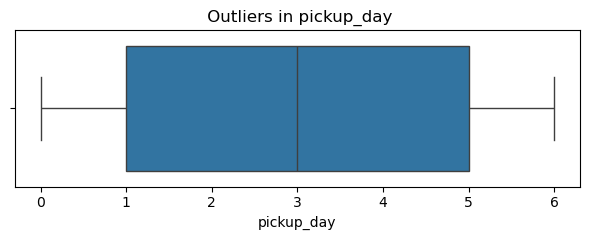

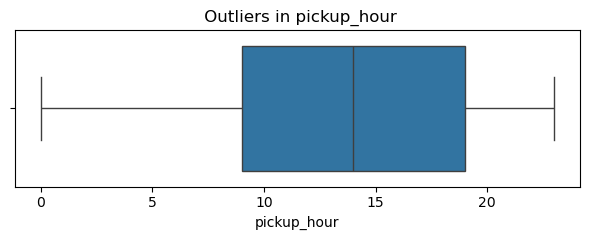

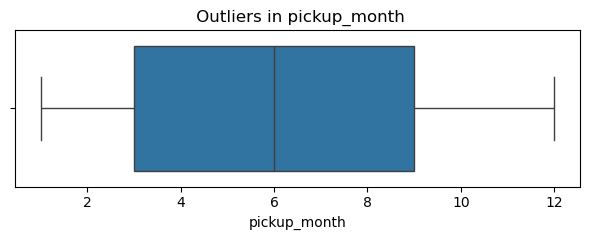

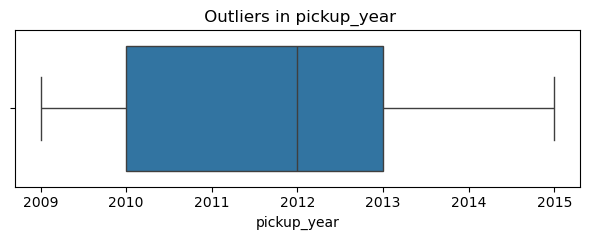

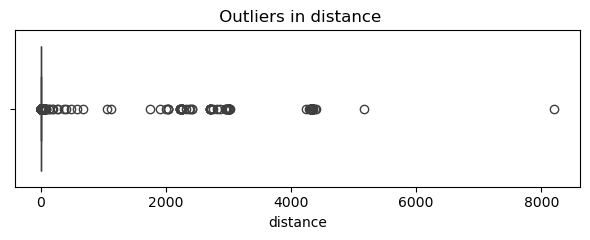

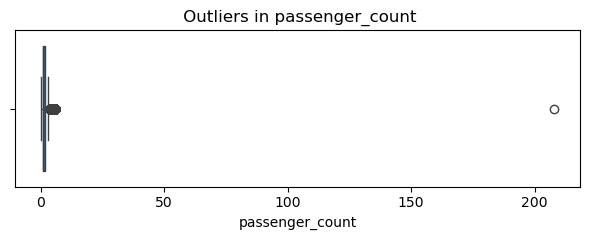

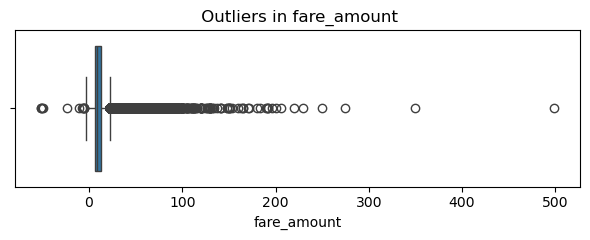

In [34]:
# indentifeied the columns having Outliers by ploting boxplot for every feature

col = list(uber_data.columns)

for i in col:
    plt.figure(figsize = (6, 2.5))
    sns.boxplot(x=uber_data[i])
    plt.title(f' Outliers in {i}')
    plt.tight_layout()
    plt.show()

####  So here we can see the ouliers in the columns "Distance", "Passenger_count" and "Fare_amount", now we will treat them one-by-one with "Capping and Flooring"..

#### Distance---

In [1]:
sns.boxplot(x=uber_data['distance'])

NameError: name 'sns' is not defined

In [36]:
uber_data['distance'].describe()

count    199999.000000
mean         10.430948
std         191.542432
min           0.000000
25%           0.607802
50%           1.060829
75%           1.938193
max        8207.195182
Name: distance, dtype: float64

In [37]:
# Cap distance outliers using 99th percentile
upper_limit = uber_data['distance'].quantile(0.99)
uber_data = uber_data[uber_data['distance'] <= upper_limit]

<Axes: xlabel='distance'>

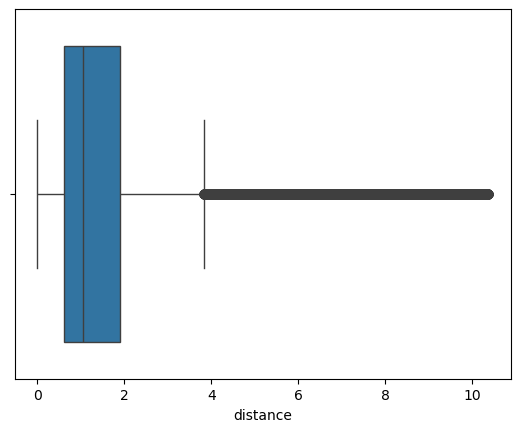

In [38]:
sns.boxplot(x=uber_data['distance'])


In [39]:
uber_data['distance'].describe()

count    197999.000000
mean          1.555967
std           1.591925
min           0.000000
25%           0.603713
50%           1.050121
75%           1.895450
max          10.364259
Name: distance, dtype: float64

#### Fare_amount---

<Axes: xlabel='fare_amount'>

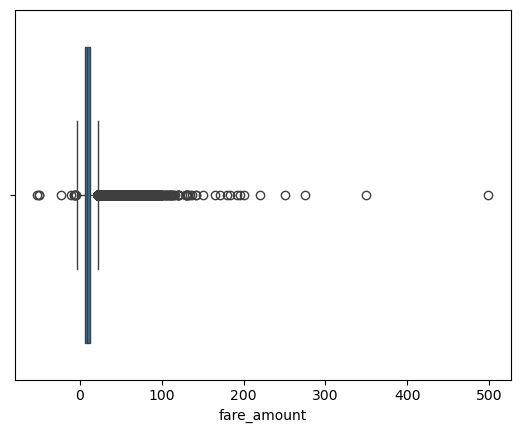

In [40]:
sns.boxplot(x=uber_data['fare_amount'])

In [41]:
uber_data['fare_amount'].describe()

count    197999.000000
mean         11.019518
std           9.041972
min         -52.000000
25%           6.000000
50%           8.500000
75%          12.500000
max         499.000000
Name: fare_amount, dtype: float64

In [42]:
upper_limit = uber_data['fare_amount'].quantile(0.99)
lower_limit = uber_data['fare_amount'].quantile(0.01)
uber_data = uber_data[uber_data['fare_amount'] <= upper_limit]
uber_data = uber_data[uber_data['fare_amount']>= lower_limit]

<Axes: xlabel='fare_amount'>

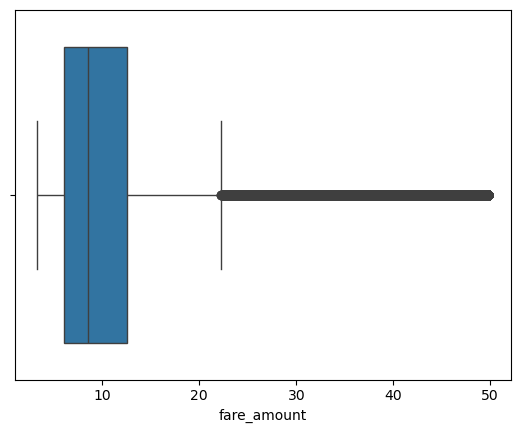

In [43]:
sns.boxplot(x = uber_data['fare_amount'])

In [44]:
uber_data['fare_amount'].describe()

count    194575.000000
mean         10.625745
std           7.403533
min           3.300000
25%           6.000000
50%           8.500000
75%          12.500000
max          49.800000
Name: fare_amount, dtype: float64

#### Passenger_count---

<Axes: xlabel='passenger_count'>

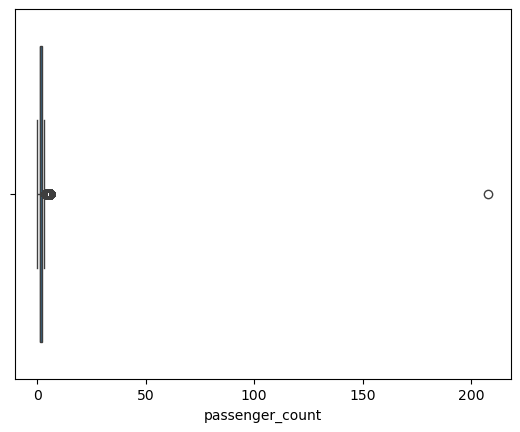

In [45]:
sns.boxplot(x = uber_data['passenger_count'])

In [46]:
uber_data['passenger_count'].describe()

count    194575.000000
mean          1.685607
std           1.389054
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         208.000000
Name: passenger_count, dtype: float64

In [47]:
uber_data[uber_data['passenger_count'] ==0]

,pickup_day,pickup_hour,pickup_month,pickup_year,distance,passenger_count,fare_amount
333,4,7,8,2011,2.481063,0,10.1
908,1,12,9,2011,1.081757,0,11.7
926,0,18,3,2012,0.175017,0,3.3
2000,4,15,4,2012,1.836165,0,15.7
3011,5,19,1,2012,0.895966,0,6.1
...,...,...,...,...,...,...,...
196797,0,15,1,2011,0.360359,0,3.3
197103,5,15,12,2011,0.000000,0,7.3
198872,1,19,9,2011,0.883010,0,5.7
198902,0,21,8,2011,1.912232,0,12.1


In [48]:
upper = uber_data['passenger_count'].quantile(0.99)
lower = uber_data['passenger_count'].quantile(0.01)
uber_data = uber_data[uber_data['passenger_count'] <= upper]
uber_data = uber_data[uber_data['passenger_count']>= lower]

<Axes: xlabel='passenger_count'>

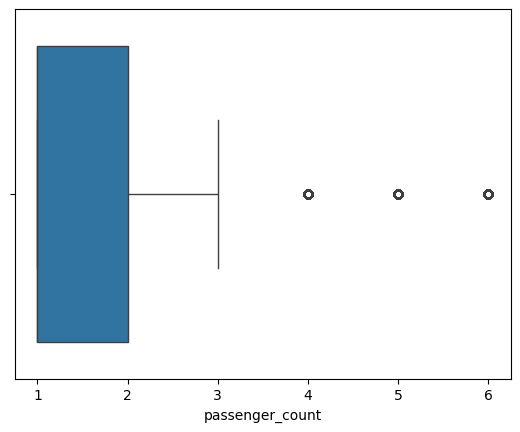

In [49]:
sns.boxplot(x = uber_data['passenger_count'])

In [50]:
uber_data['passenger_count'].describe()

count    193882.000000
mean          1.690559
std           1.306390
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: passenger_count, dtype: float64

## Co-releation analysis

In [132]:
# to find the co-relation of all independent variables  with the target variable...
round(uber_data.corr(), 2)

,pickup_day,pickup_hour,pickup_month,pickup_year,distance,passenger_count,fare_amount
pickup_day,1.00,-0.09,-0.01,0.01,0.02,0.04,0.01
pickup_hour,-0.09,1.00,-0.00,0.00,-0.04,0.01,-0.02
pickup_month,-0.01,-0.00,1.00,-0.11,0.01,0.01,0.03
pickup_year,0.01,0.00,-0.11,1.00,-0.00,0.00,0.11
distance,0.02,-0.04,0.01,-0.00,1.00,0.01,0.85
passenger_count,0.04,0.01,0.01,0.00,0.01,1.00,0.01
fare_amount,0.01,-0.02,0.03,0.11,0.85,0.01,1.00


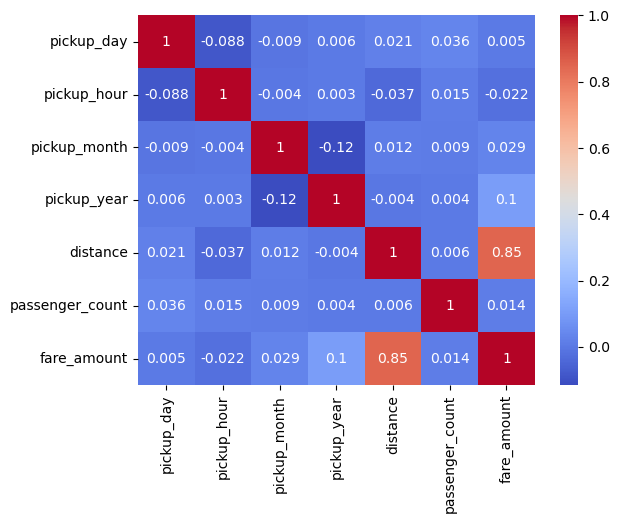

In [133]:
# to show the co-relation through 'Heatmap'

sns.heatmap(round(uber_data.corr(), 3), cmap = 'coolwarm', annot = True)
plt.show()

In [134]:
print(uber_data.corr()['fare_amount'].sort_values( ascending = False ))

fare_amount        1.000000
distance           0.850862
pickup_year        0.105449
pickup_month       0.028657
passenger_count    0.013660
pickup_day         0.005362
pickup_hour       -0.021837
Name: fare_amount, dtype: float64


As we can see a good co-relation "0.85" between "distance" and target variable, so now we will go first with "distance" variable and then with all the features and then will try to find out the best fit model with minimum error...

## Split the Dataset

In [51]:
uber_data.columns

Index(['pickup_day', 'pickup_hour', 'pickup_month', 'pickup_year', 'distance',
       'passenger_count', 'fare_amount'],
      dtype='object')

In [52]:
# to segregate all independent & target variables in to X, y...
X = uber_data[[ 'pickup_day', 'pickup_hour', 'pickup_month', 'pickup_year', 'distance',
       'passenger_count']]
y = np.log1p(uber_data['fare_amount'])

In [53]:
X.head(3)

,pickup_day,pickup_hour,pickup_month,pickup_year,distance,passenger_count
0,3,19,5,2015,0.841926,1
1,4,20,7,2009,1.229181,1
2,0,21,8,2009,2.518979,1


In [54]:
# to spilt the whole data into train & test data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state = 25)

In [55]:
# to find the number of rows and columns to train the data
X_train.shape

(135717, 6)

In [56]:
# to find the number of rows and columns to test the data
X_test.shape

(58165, 6)

In [57]:
y_train.shape

(135717,)

In [58]:
y_test.shape

(58165,)

In [59]:
y_train.isna().sum()

np.int64(0)

## Data Scaling/Normalization

In [60]:
print(X_train.shape, X_test.shape)

(135717, 6) (58165, 6)


In [61]:
scalar = MinMaxScaler()

In [62]:
# scaled the data to bring all features on same scale..

scalar.fit(X_train)    # will fit the minmaxscaler on train data, but transform on both, train and test data...

MinMaxScaler()

In [63]:
X_train_scaled = scalar.transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [64]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [65]:
X_train.describe()

,pickup_day,pickup_hour,pickup_month,pickup_year,distance,passenger_count
count,135717.000000,135717.000000,135717.000000,135717.000000,135717.000000,135717.000000
mean,3.050318,13.488406,6.285734,2011.727816,1.517332,1.691056
std,1.946875,6.527616,3.438401,1.856924,1.465191,1.308196
min,0.000000,0.000000,1.000000,2009.000000,0.000000,1.000000
25%,1.000000,9.000000,3.000000,2010.000000,0.611856,1.000000
50%,3.000000,14.000000,6.000000,2012.000000,1.051740,1.000000
75%,5.000000,19.000000,9.000000,2013.000000,1.880337,2.000000
max,6.000000,23.000000,12.000000,2015.000000,10.364259,6.000000


In [66]:
X_train_scaled.describe()

,pickup_day,pickup_hour,pickup_month,pickup_year,distance,passenger_count
count,135717.000000,135717.000000,135717.000000,135717.000000,135717.000000,135717.000000
mean,0.508386,0.586452,0.480521,0.454636,0.146400,0.138211
std,0.324479,0.283809,0.312582,0.309487,0.141370,0.261639
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.166667,0.391304,0.181818,0.166667,0.059035,0.000000
50%,0.500000,0.608696,0.454545,0.500000,0.101478,0.000000
75%,0.833333,0.826087,0.727273,0.666667,0.181425,0.200000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Selection and training of Regression Model

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor as DTR
from sklearn.metrics import mean_squared_error as mse 
from sklearn.metrics import mean_absolute_error as mae 
from sklearn.metrics import r2_score


## Using Linear Regression

#### with Distance feature

In [71]:
linear_model = LinearRegression()
linear_model

LinearRegression()

In [72]:
X_train_dis = X_train_scaled[['distance']]
X_test_dis = X_test_scaled[['distance']]

In [73]:
linear_model.fit(X_train_dis, y_train)

LinearRegression()

In [74]:
linear_dis = linear_model.predict(X_test_dis)

#### with all features

In [75]:
linear_model_all = LinearRegression()
linear_model_all 

LinearRegression()

In [76]:
linear_model_all.fit(X_train_scaled, y_train)

LinearRegression()

In [77]:
y_predict_forall = linear_model_all.predict(X_test_scaled)

In [90]:
# -- error and r2 score for Distance variable 
dis_mse = mse(y_test, linear_dis)
print(f'error with only "Distance" variable--    {dis_mse}')                              # error with only "Distance" variable....

dis_r2 = r2_score(y_test, linear_dis)
print(f'r2_score for "Distance" & "Target Variable" variable--   {dis_r2}')             # r2_score for "Distance" & "Target Variable" variable....


# -- error and r2 score for all features
linear_ms = mse(y_test, y_predict_forall)
print(f'error for all variables--   {linear_ms}')                             # error for all variable....

linear_r2 = r2_score(y_test, y_predict_forall)
print(f'r2_score for all variables--  {linear_r2}')                      # r2_score for all variables....

error with only "Distance" variable--    0.0837478509616099
r2_score for "Distance" & "Target Variable" variable--   0.6570658025653962
error for all variables--   0.07865764997477502
r2_score for all variables--  0.677909370133491


## Using Decision Tree

In [135]:
X_dtrain_dis = X_train_scaled[['distance']]
X_dtest_dis = X_test_scaled[['distance']]

In [136]:
DT_model_dis = DTR()                  
DT_model_dis

DecisionTreeRegressor()

In [139]:
DT_model_dis.fit(X_dtrain_dis, y_train)

DecisionTreeRegressor()

In [140]:
DT_predict_dis = DT_model_dis.predict(X_dtest_dis)

In [141]:
DT_model = DTR()               
DT_model

DecisionTreeRegressor()

In [142]:
DT_model.fit(X_train_scaled, y_train)

DecisionTreeRegressor()

In [143]:
DT_predict = DT_model.predict(X_test_scaled)

In [144]:
predict_train = DT_model.predict(X_train_scaled)

In [145]:
# -- error and r2 score for Distance variable 
DT_mse_dis = mse(y_test, DT_predict_dis)
print(f'error with only "Distance" variable--   {DT_mse_dis}')                 # error for distance variable

DT_r2_dis = r2_score(y_test, DT_predict_dis)
print(f'r2_score for "Distance" & "Target Variable" variable--     {DT_r2_dis}')              #r2_score for Distance variable


# -- error and r2 score for all features
DT_mse = mse(y_test, DT_predict)
print(f'error for all variable--    {DT_mse}')                               # error for all Variables

DT_r2 = r2_score(y_test, DT_predict)
print(f'r2_score for all variable--   {DT_r2}')                              # r2_score for all variables



# -- error and r2 score for train data to check if the model is over-fitted 
DT_mse = mse(y_train, predict_train)
print(f'error for train variable--    {DT_mse}')                                              # error on train data

DT_r2 = r2_score(y_train, predict_train)
print(f'r2_score for train variable--   {DT_r2}')                                             # r2_score on train data

error with only "Distance" variable--   0.11097689937547515
r2_score for "Distance" & "Target Variable" variable--     0.545567158033045
error for all variable--    0.10650923845242743
r2_score for all variable--   0.5638615225506209
error for all variable--    0.0006327206951887701
r2_score for all variable--   0.997449300344241


As we can see the relatively more effective results with all features so we will tune our model with all features only
also the model is overfitting, it is performing extremely good/accurate on train data and giving r2_score but on test data it's performing very poor, now we will tune our model by fixing the max_depth

### fine-tuning by fixing the depth 

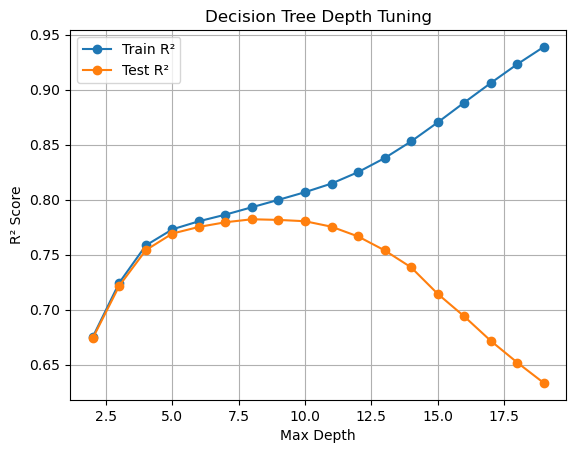

In [147]:
# now to pick a perfect depth let's check the graph of r2_score on train data and test data, this is how ww will measure from where the model started overfitting..

depths = range(2, 20)
train_r2, test_r2 = [], []

for d in depths:
    model = DTR(max_depth=d)
    model.fit(X_train_scaled, y_train)
    train_r2.append(r2_score(y_train, model.predict(X_train_scaled)))
    test_r2.append(r2_score(y_test, model.predict(X_test_scaled)))

plt.plot(depths, train_r2, label='Train R²', marker='o')
plt.plot(depths, test_r2, label='Test R²', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('R² Score')
plt.title('Decision Tree Depth Tuning')
plt.legend()
plt.grid(True)
plt.show()

here we can clearly find that on "max_depth = 8 " giving the highest r2_score and the model is not overfiiting too.

In [123]:
DTM_final = DTR(max_depth = 8)
DTM_final

DecisionTreeRegressor(max_depth=8)

In [148]:
DTM_final.fit(X_train_scaled, y_train)

DecisionTreeRegressor(max_depth=8)

In [149]:
final_predict = DTM_final.predict(X_test_scaled)

In [151]:
# error and r2 score (on train and test data) with max_depth = 8

print("Train R²:", round(r2_score(y_train, DTM_final.predict(X_train_scaled)), 4))
print("Test R² :", round(r2_score(y_test, final_predict), 4))
print("MSE     :", round(mse(y_test, final_predict), 4))

Train R²: 0.7932
Test R² : 0.7822
MSE     : 0.0532


By fixing the max_depth value , we did get a very good and positive change in the terms of accuracy of our model

In [153]:
# Final lookout on all the outputs

results = {
    'Model': ['LR - Distance Only', 'LR - All Features', 
              'DT - No Depth Limit', 'DT - max_depth=8'],
    'MSE':   [0.0837, 0.0787, 0.1065, 0.0532],
    'R²':    [0.657,  0.678,  0.563,  0.7822]
}
pd.DataFrame(results).sort_values('R²', ascending=False)

,Model,MSE,R²
3,DT - max_depth=8,0.0532,0.7822
1,LR - All Features,0.0787,0.6780
0,LR - Distance Only,0.0837,0.6570
2,DT - No Depth Limit,0.1065,0.5630


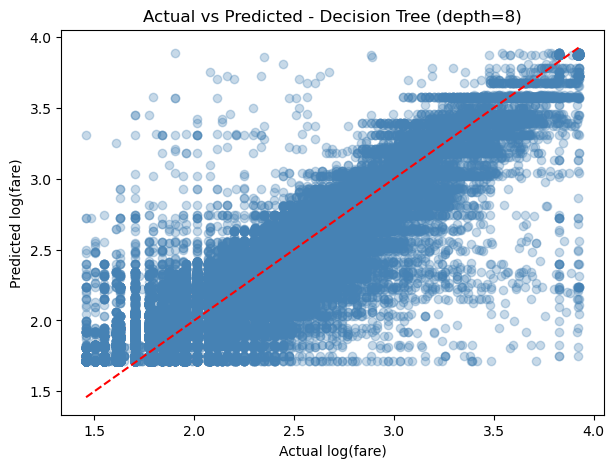

In [154]:
# plot between actual and predict values

plt.figure(figsize=(7,5))
plt.scatter(y_test, final_predict, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual log(fare)')
plt.ylabel('Predicted log(fare)')
plt.title('Actual vs Predicted - Decision Tree (depth=8)')
plt.show()

# -- THANK YOU --